## Part 1: Dataset Loading

In [10]:
pip install ucimlrepo

In [11]:
# Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay,
                             PrecisionRecallDisplay, average_precision_score)

## Part 2: Modeling and Evaluation

In [12]:
# TRAIN-TEST SPLIT
from sklearn.model_selection import train_test_split

df_encoded = pd.read_csv('processed_diabetes_data.csv')

X = df_encoded.drop(columns=['readmit_30', 'original_race'])
y = df_encoded['readmit_30']
race_column = df_encoded['original_race']

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Also split the race column in the same way for Part 5
race_train, race_test = train_test_split(
    race_column, test_size=0.2, random_state=42, stratify=y
)

# How many are labeled as "readmitted within 30 days"
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.2%}")
print(f"Test positive rate:  {y_test.mean():.2%}")

Train: (80195, 2365), Test: (20049, 2365)
Train positive rate: 11.22%
Test positive rate:  11.22%


In [13]:
# RANDOM FOREST MODEL
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=20,
    class_weight='balanced',   # handle imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# for confusion matrix, classification report
y_pred = rf.predict(X_test)
# for ROC curve, PR curve
y_prob = rf.predict_proba(X_test)[:, 1]

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=['No Readmit', 'Readmit <30']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Classification Report
              precision    recall  f1-score   support

  No Readmit       0.93      0.66      0.77     17799
 Readmit <30       0.18      0.58      0.27      2250

    accuracy                           0.65     20049
   macro avg       0.55      0.62      0.52     20049
weighted avg       0.84      0.65      0.72     20049

ROC-AUC: 0.6718


In [14]:
"""
For each of the 20,049 test patients, it outputs a risk score between 0 and 1.
The hospital then has to draw a line somewhere. Everyone above that line gets flagged for follow-up.
"""

'\nFor each of the 20,049 test patients, it outputs a risk score between 0 and 1.\nThe hospital then has to draw a line somewhere. Everyone above that line gets flagged for follow-up.\n'

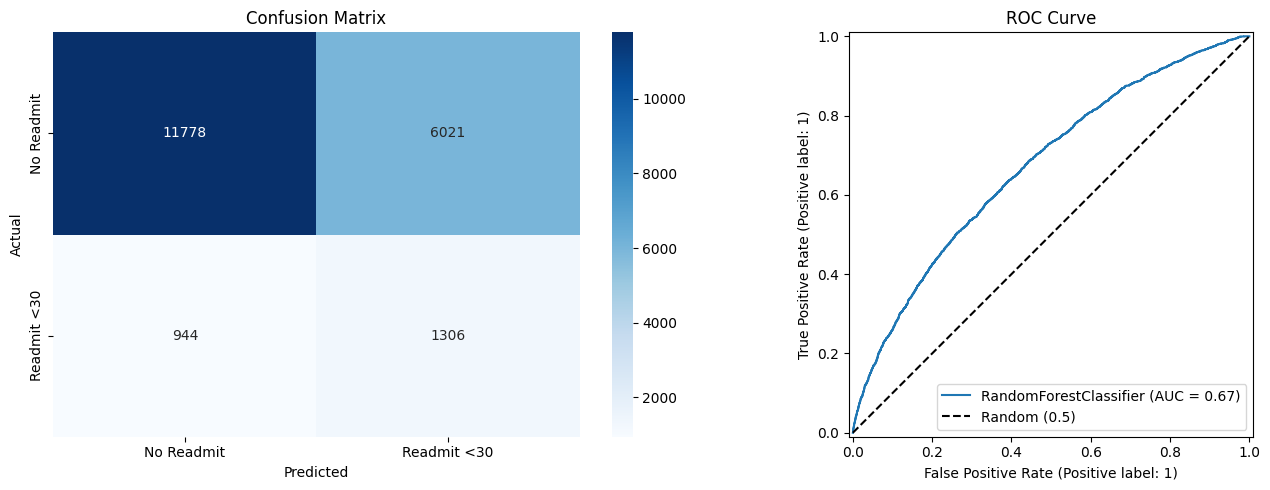

In [15]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Readmit', 'Readmit <30'],
            yticklabels=['No Readmit', 'Readmit <30'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# ROC Curve
# For overall performance
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', label='Random (0.5)')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

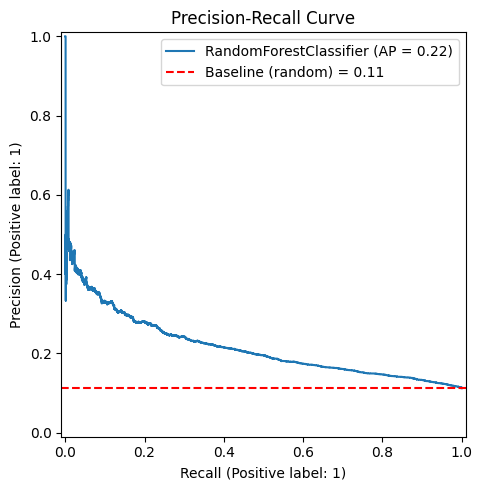

Average Precision (AP): 0.2159


In [16]:
# PR Curve
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

fig, ax = plt.subplots(figsize=(8, 5))
PrecisionRecallDisplay.from_estimator(rf, X_test, y_test, ax=ax)

# Baseline = positive class rate (what random guessing would give)
baseline = y_test.mean()
ax.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline (random) = {baseline:.2f}')
ax.set_title('Precision-Recall Curve')
ax.legend()
plt.tight_layout()
plt.show()

ap = average_precision_score(y_test, y_prob)
print(f"Average Precision (AP): {ap:.4f}")

In [17]:
"""
AP = 0.22 means on average across all thresholds, about 22% of the model's flagged patients are truly readmitted.
This means a broader group of people are flagged -> a waste of resources

Compare that to the baseline of 11% (random guessing). So the model is roughly 2x better than random — meaningful, but far from great.
"""

"\nAP = 0.22 means on average across all thresholds, about 22% of the model's flagged patients are truly readmitted.\nThis means a broader group of people are flagged -> a waste of resources\n\nCompare that to the baseline of 11% (random guessing). So the model is roughly 2x better than random — meaningful, but far from great.\n"

In [18]:
"""
In an ideal world (AP = 1.0), would flag exactly those patients who is admitted within 30 days and nobody else.

At AP = 0.22, about 78% of the model's flags are still false alarms.
The model is doing meaningful work above random, but a doctor looking at the flagged list would find that most flagged patients don't actually get readmitted. There's a lot of room for improvement.
"""

"\nIn an ideal world (AP = 1.0), would flag exactly those patients who is admitted within 30 days and nobody else.\n\nAt AP = 0.22, about 78% of the model's flags are still false alarms.\nThe model is doing meaningful work above random, but a doctor looking at the flagged list would find that most flagged patients don't actually get readmitted. There's a lot of room for improvement.\n"

In [19]:
"""
This is different from the one in lecture slide because the following:
- The baseline is a flat line at 0.11, not a diagonal at 0.5. That's because only 11% of patients are positive.
  A random model would achieve 11% precision at every recall level — hence the flat red dashed line.
- There is severe imbalance.
"""

"\nThis is different from the one in lecture slide because the following:\n- The baseline is a flat line at 0.11, not a diagonal at 0.5. That's because only 11% of patients are positive.\n  A random model would achieve 11% precision at every recall level — hence the flat red dashed line.\n- There is severe imbalance.\n"

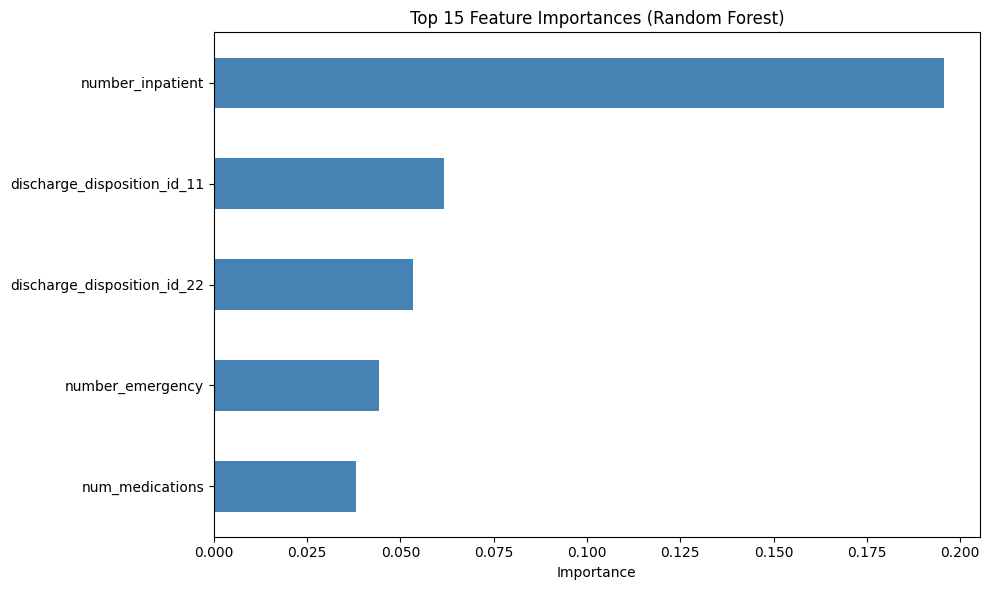

In [20]:
# Top 15 most important features
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.nlargest(5).sort_values().plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [21]:
# AI SAFETY & BIAS AUDIT

# Compute False Negative Rate (FNR) by race
# FNR = FN / (FN + TP)

results = pd.DataFrame({
    'race': race_test.values,
    'y_true': y_test.values,
    'y_pred': y_pred
})

def compute_fnr(group):
    actual_pos = group[group['y_true'] == 1]
    if len(actual_pos) == 0:
        return np.nan
    fn = ((actual_pos['y_true'] == 1) & (actual_pos['y_pred'] == 0)).sum()
    tp = ((actual_pos['y_true'] == 1) & (actual_pos['y_pred'] == 1)).sum()
    return fn / (fn + tp)

fnr_by_race = results.groupby('race').apply(compute_fnr).reset_index()
fnr_by_race.columns = ['race', 'fnr']

# Also get group sizes for context
group_sizes = results.groupby('race')['y_true'].agg(['count', 'sum']).reset_index()
group_sizes.columns = ['race', 'total', 'actual_positive']
fnr_by_race = fnr_by_race.merge(group_sizes, on='race')

print("False Negative Rate by Race")
print(fnr_by_race.to_string(index=False))

False Negative Rate by Race
           race      fnr  total  actual_positive
AfricanAmerican 0.411085   3776              433
          Asian 0.470588    132               17
      Caucasian 0.420046  15454             1726
       Hispanic 0.448980    413               49
          Other 0.440000    274               25


/tmp/ipykernel_33222/761091745.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fnr_by_race = results.groupby('race').apply(compute_fnr).reset_index()


In [22]:
"""
All groups have fairly similar false negative rates, ranging from 0.41 (African American) to 0.47 (Asian).
The model misses roughly 41-47% of truly high-risk patients across all racial groups. No single group stands out as dramatically worse.
"""

'\nAll groups have fairly similar false negative rates, ranging from 0.41 (African American) to 0.47 (Asian).\nThe model misses roughly 41-47% of truly high-risk patients across all racial groups. No single group stands out as dramatically worse.\n'

/tmp/ipykernel_33222/3332088207.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(fnr_by_race['race'], rotation=30, ha='right')
/tmp/ipykernel_33222/3332088207.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(fnr_by_race['race'], rotation=30, ha='right')


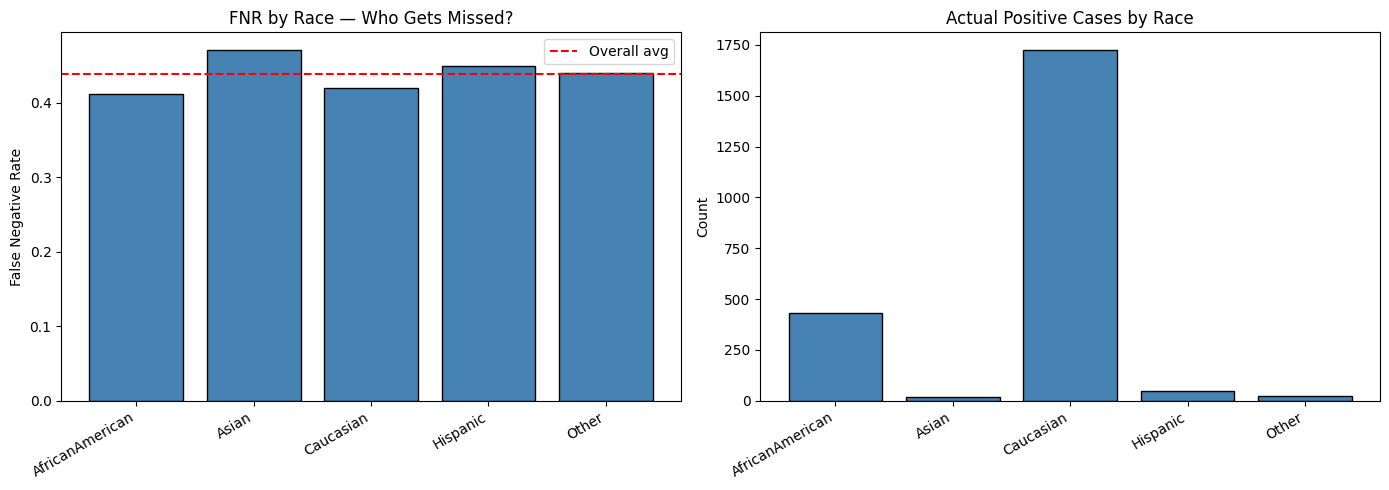

In [23]:
# Visualize FNR disparity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FNR bar chart
bars = axes[0].bar(fnr_by_race['race'], fnr_by_race['fnr'],
                    color=['steelblue' for r in fnr_by_race['race']],
                    edgecolor='black')
axes[0].set_ylabel('False Negative Rate')
axes[0].set_title('FNR by Race — Who Gets Missed?')
axes[0].set_xticklabels(fnr_by_race['race'], rotation=30, ha='right')
axes[0].axhline(y=fnr_by_race['fnr'].mean(), color='red', linestyle='--', label='Overall avg')
axes[0].legend()

# Group sizes
axes[1].bar(fnr_by_race['race'], fnr_by_race['actual_positive'], color='steelblue', edgecolor='black')
axes[1].set_ylabel('Count')
axes[1].set_title('Actual Positive Cases by Race')
axes[1].set_xticklabels(fnr_by_race['race'], rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [24]:
# Permutation Test — Is the FNR gap statistically significant or just noise?

# H_0: Race has no effect on FNR

# Compare AfricanAmerican vs Caucasian (two largest groups)

aa_mask = results['race'] == 'AfricanAmerican'
cau_mask = results['race'] == 'Caucasian'
subset = results[aa_mask | cau_mask].copy()

# Observed FNR difference
observed_fnr_aa = compute_fnr(subset[subset['race'] == 'AfricanAmerican'])
observed_fnr_cau = compute_fnr(subset[subset['race'] == 'Caucasian'])
observed_diff = observed_fnr_aa - observed_fnr_cau
print(f"Observed FNR: African American = {observed_fnr_aa:.4f}, Caucasian = {observed_fnr_cau:.4f}")
print(f"Observed FNR Difference (AA - Caucasian): {observed_diff:.4f}")

# Permutation test: shuffle race labels 10,000 times
n_permutations = 10000
perm_diffs = []

for i in range(n_permutations):
    shuffled_race = np.random.permutation(subset['race'].values)
    subset_shuffled = subset.copy()
    subset_shuffled['race'] = shuffled_race

    fnr_aa_perm = compute_fnr(subset_shuffled[subset_shuffled['race'] == 'AfricanAmerican'])
    fnr_cau_perm = compute_fnr(subset_shuffled[subset_shuffled['race'] == 'Caucasian'])
    perm_diffs.append(fnr_aa_perm - fnr_cau_perm)

perm_diffs = np.array(perm_diffs)

# P-value: proportion of permuted diffs as extreme as observed
p_value = (np.abs(perm_diffs) >= np.abs(observed_diff)).mean()
print(f"\nPermutation Test P-value: {p_value:.4f}")
print(f"Statistically significant at α=0.05? {'YES' if p_value < 0.05 else 'NO'}")

Observed FNR: African American = 0.4111, Caucasian = 0.4200
Observed FNR Difference (AA - Caucasian): -0.0090

Permutation Test P-value: 0.7311
Statistically significant at α=0.05? NO


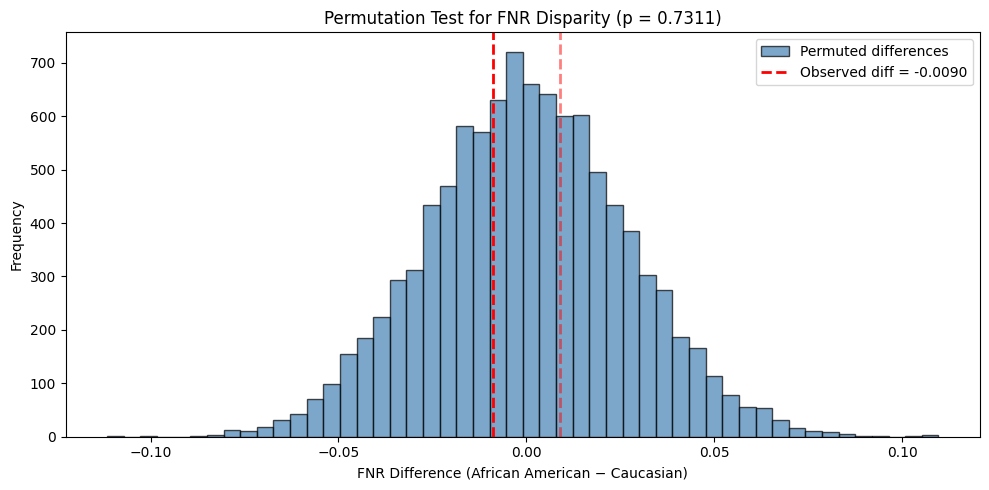

In [25]:
# Visualize the permutation test
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, color='steelblue', edgecolor='black', alpha=0.7, label='Permuted differences')
plt.axvline(observed_diff, color='red', linewidth=2, linestyle='--',
            label=f'Observed diff = {observed_diff:.4f}')
plt.axvline(-observed_diff, color='red', linewidth=2, linestyle='--', alpha=0.5)
plt.xlabel('FNR Difference (African American − Caucasian)')
plt.ylabel('Frequency')
plt.title(f'Permutation Test for FNR Disparity (p = {p_value:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
"""
We cannot conclude that the model treats African American patients differently from Caucasian patients in terms of missed diagnoses.
The small FNR gap we observed is statistically indistinguishable from what you'd get by random chance.
"""

"\nWe cannot conclude that the model treats African American patients differently from Caucasian patients in terms of missed diagnoses.\nThe small FNR gap we observed is statistically indistinguishable from what you'd get by random chance.\n"